<a href="https://colab.research.google.com/github/DanielRegaladoUMiami/counterflow-nn/blob/main/notebooks/01_phase2_distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFNN Phase 2 — Distillation Architecture & Diagnostics

This notebook runs all Phase 2 experiments:
1. **Setup**: Clone repo & install dependencies
2. **Unit Tests**: Verify CFNN-D conservation, reflux, bidirectional transfer
3. **Tier 2**: CFNN-D vs CFNN-A vs MLP on UCI datasets + California Housing
4. **Tier 3**: MNIST & FashionMNIST (scale-up test)
5. **Diagnostics**: Damköhler numbers, Murphree efficiency, NTU
6. **Distillation Internals**: Rectifying vs stripping dynamics

**Author:** Daniel Regalado Cardoso | University of Miami

## 1. Setup

In [1]:
# Clone the repo (use the phase-2 branch)
!git clone -b main https://github.com/DanielRegaladoUMiami/counterflow-nn.git
%cd counterflow-nn

Cloning into 'counterflow-nn'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 77 (delta 28), reused 60 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 1.10 MiB | 9.90 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/counterflow-nn


In [2]:
# Install dependencies
!pip install scikit-learn matplotlib pandas pytest torchvision -q

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Import all CFNN modules
from src.plates import CounterFlowPlate
from src.network import CounterFlowNetwork
from src.distillation import DistillationPlate, DistillationNetwork
from src.activations import MichaelisMenten, Arrhenius, HillActivation, Autocatalytic
from src.diagnostics import (
    damkohler_number, murphree_efficiency, number_of_transfer_units,
    alpha_statistics, operating_line_data, print_diagnostics
)
from src.utils import load_synthetic_dataset, load_uci_dataset, prepare_data, train_model
print("All imports successful!")

PyTorch: 2.10.0+cu128
CUDA available: True
All imports successful!


## 2. Unit Tests — CFNN-D

In [4]:
!python -m pytest tests/test_distillation.py -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/counterflow-nn
configfile: pyproject.toml
plugins: typeguard-4.5.1, anyio-4.12.1, langsmith-0.7.16
collected 24 items                                                             

tests/test_distillation.py::TestDistillationPlate::test_output_dimensions PASSED [  4%]
tests/test_distillation.py::TestDistillationPlate::test_bidirectional_conservation PASSED [  8%]
tests/test_distillation.py::TestDistillationPlate::test_alpha_positive PASSED [ 12%]
tests/test_distillation.py::TestDistillationPlate::test_beta_positive PASSED [ 16%]
tests/test_distillation.py::TestDistillationPlate::test_beta_init_value PASSED [ 20%]
tests/test_distillation.py::TestDistillationPlate::test_gradients_flow PASSED [ 25%]
tests/test_distillation.py::TestDistillationPlate::test_has_reverse_transfer PASSED [ 29%]


## 3. Quick Sanity Check — Does CFNN-D Learn?

In [5]:
# Sanity check: CFNN-D on moons
X, y = load_synthetic_dataset("moons", n_samples=1000, noise=0.2, seed=42)
train_loader, test_loader, d_in, n_classes = prepare_data(X, y, seed=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create CFNN-D
cfnn_d = DistillationNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates_rect=3, n_plates_strip=2,
    d_out=n_classes, n_sweeps=2,
    reflux_ratio=0.3, reboil_ratio=0.2,
)
print(f"CFNN-D Parameters: {cfnn_d.count_parameters()}")
print(f"Reflux ratio: {cfnn_d.reflux_ratio.item():.4f}")
print(f"Reboil ratio: {cfnn_d.reboil_ratio.item():.4f}")

history_d = train_model(
    cfnn_d, train_loader, test_loader,
    n_epochs=100, lr=1e-3, device=device,
    verbose=True, print_every=10
)

print(f"\nBest CFNN-D accuracy: {max(history_d['test_metrics']):.4f}")
print(f"Learned reflux ratio: {cfnn_d.reflux_ratio.item():.4f}")
print(f"Learned reboil ratio: {cfnn_d.reboil_ratio.item():.4f}")

CFNN-D Parameters: 10853
Reflux ratio: 0.3000
Reboil ratio: 0.2000
Epoch   10 | Train: 0.2747 | Test: 0.2038 | accuracy: 0.9300
Epoch   20 | Train: 0.1458 | Test: 0.0830 | accuracy: 0.9750
Epoch   30 | Train: 0.0784 | Test: 0.0332 | accuracy: 0.9900
Epoch   40 | Train: 0.0739 | Test: 0.0267 | accuracy: 0.9900
Epoch   50 | Train: 0.0698 | Test: 0.0240 | accuracy: 0.9900
Epoch   60 | Train: 0.0713 | Test: 0.0245 | accuracy: 0.9950
Epoch   70 | Train: 0.0728 | Test: 0.0289 | accuracy: 0.9900
Epoch   80 | Train: 0.0666 | Test: 0.0234 | accuracy: 0.9950
Epoch   90 | Train: 0.0626 | Test: 0.0261 | accuracy: 0.9900
Epoch  100 | Train: 0.0671 | Test: 0.0225 | accuracy: 0.9950

Best CFNN-D accuracy: 1.0000
Learned reflux ratio: 0.3270
Learned reboil ratio: 0.2273


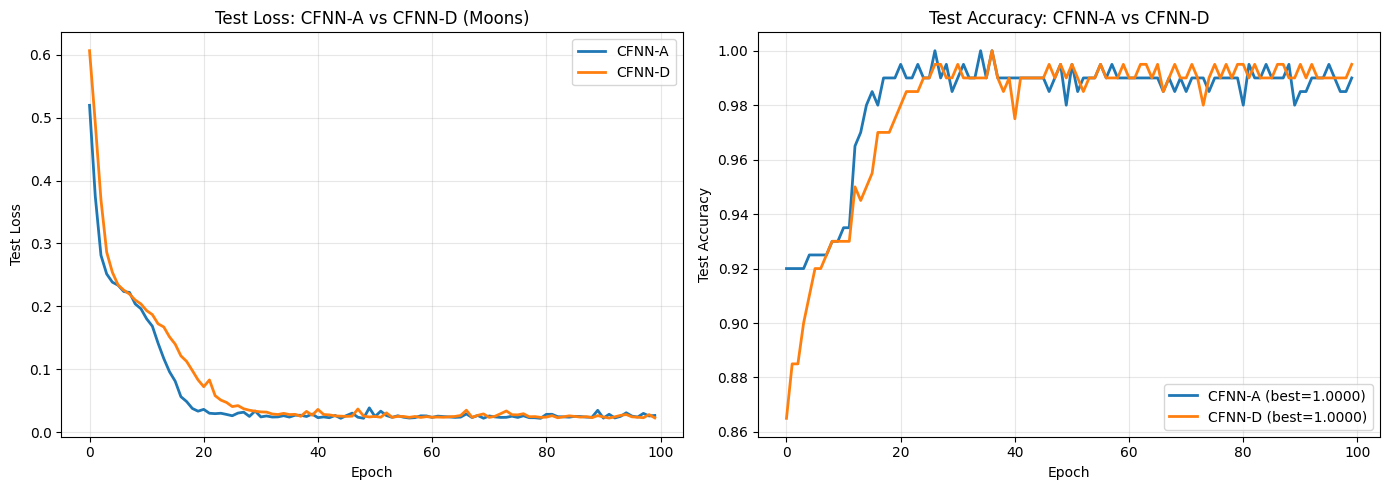

In [6]:
# Compare CFNN-A vs CFNN-D training curves on moons
cfnn_a = CounterFlowNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates=5, d_out=n_classes, n_sweeps=2
)
history_a = train_model(
    cfnn_a, train_loader, test_loader,
    n_epochs=100, lr=1e-3, device=device, verbose=False
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_a['test_losses'], label='CFNN-A', linewidth=2)
ax1.plot(history_d['test_losses'], label='CFNN-D', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Test Loss')
ax1.set_title('Test Loss: CFNN-A vs CFNN-D (Moons)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history_a['test_metrics'], label=f'CFNN-A (best={max(history_a["test_metrics"]):.4f})', linewidth=2)
ax2.plot(history_d['test_metrics'], label=f'CFNN-D (best={max(history_d["test_metrics"]):.4f})', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Test Accuracy')
ax2.set_title('Test Accuracy: CFNN-A vs CFNN-D')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Tier 2 — Full Comparison (UCI + Synthetic)

In [7]:
# Run the full Tier 2 comparison
# Takes ~10-15 minutes on GPU
!python experiments/tier2_distillation.py


Running Tier 2: moons

  CFNN Diagnostics Report: CFNN-A on moons
  Parameters: 4386

--- Transfer Coefficients ---
  _shared_plate: alpha_mean=0.1162, range=[0.1040, 0.1375]

--- Damkohler Numbers ---
  Da_mean = 1.0000 +/- 0.0000
  Plate 0: Da = 1.0000 [HIGH]
  Plate 1: Da = 1.0000 [OK]
  Plate 2: Da = 1.0000 [OK]
  Plate 3: Da = 1.0000 [OK]
  Plate 4: Da = 1.0000 [OK]

--- Network Transfer Units ---
  NTU = 0.5393

--- Murphree Plate Efficiency ---
  eta_mean = 0.1217 +/- 0.0032
  Plate 0: eta = 0.1245
  Plate 1: eta = 0.1246
  Plate 2: eta = 0.1231
  Plate 3: eta = 0.1202
  Plate 4: eta = 0.1162



  CFNN Diagnostics Report: CFNN-D on moons
  Parameters: 10853

--- Transfer Coefficients ---
  _rect_plate: alpha_mean=0.1194, range=[0.0997, 0.1590]
  _strip_plate: alpha_mean=0.1031, range=[0.0842, 0.1260]
  _rect_plate: beta_mean=0.0515, range=[0.0444, 0.0541]
  _strip_plate: beta_mean=0.0566, range=[0.0502, 0.0753]

--- Damkohler Numbers ---
  Da_mean = 0.4322 +/- 0.0175
  Plate 0:

## 5. Tier 3 — MNIST & FashionMNIST

In [8]:
# Run Tier 3 MNIST experiments
# Takes ~15-20 minutes on GPU
!python experiments/tier3_mnist.py


Tier 3: MNIST
100% 9.91M/9.91M [00:01<00:00, 5.53MB/s]
100% 28.9k/28.9k [00:00<00:00, 132kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100% 4.54k/4.54k [00:00<00:00, 17.8MB/s]
  MNIST | CFNN-A | seed 0 | params=67530
Epoch    5 | Train: 0.1106 | Test: 0.1176 | accuracy: 0.9636
Epoch   10 | Train: 0.0664 | Test: 0.1009 | accuracy: 0.9669
Epoch   15 | Train: 0.0456 | Test: 0.1148 | accuracy: 0.9666
Epoch   20 | Train: 0.0385 | Test: 0.0912 | accuracy: 0.9760
  -> Best accuracy: 0.9760

  MNIST | CFNN-D | seed 0 | params=92749
Epoch    5 | Train: 0.1137 | Test: 0.1110 | accuracy: 0.9651
Epoch   10 | Train: 0.0677 | Test: 0.0959 | accuracy: 0.9702
Epoch   15 | Train: 0.0436 | Test: 0.0977 | accuracy: 0.9699
Epoch   20 | Train: 0.0326 | Test: 0.0907 | accuracy: 0.9737
  -> Best accuracy: 0.9740

  MNIST | MLP | seed 0 | params=167362
Epoch    5 | Train: 0.0876 | Test: 0.1090 | accuracy: 0.9665
Epoch   10 | Train: 0.0500 | Test: 0.0862 | accuracy: 0.9723
Epoch   15 | Train: 0.0299 | Test: 

## 6. Diagnostics — Analyzing CFNN Internals

In [9]:
from sklearn.preprocessing import StandardScaler

# Train CFNN-A with 8 plates for rich diagnostics
X, y = load_synthetic_dataset('moons', n_samples=1000, seed=42)
train_ld, test_ld, d_in, n_cls = prepare_data(X, y, seed=42)

model_a = CounterFlowNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates=8, d_out=n_cls, n_sweeps=2
)
train_model(model_a, train_ld, test_ld, n_epochs=150, device=device, verbose=False)
model_a.to('cpu')

X_scaled = torch.FloatTensor(StandardScaler().fit_transform(X))
diag_a = print_diagnostics(model_a, X_scaled, model_name='CFNN-A (8 plates, moons)')


  CFNN Diagnostics Report: CFNN-A (8 plates, moons)
  Parameters: 4386

--- Transfer Coefficients ---
  _shared_plate: alpha_mean=0.1125, range=[0.0967, 0.1273]

--- Damkohler Numbers ---
  Da_mean = 1.0000 +/- 0.0000
  Plate 0: Da = 1.0000 [OK]
  Plate 1: Da = 1.0000 [OK]
  Plate 2: Da = 1.0000 [OK]
  Plate 3: Da = 1.0000 [OK]
  Plate 4: Da = 1.0000 [OK]
  Plate 5: Da = 1.0000 [OK]
  Plate 6: Da = 1.0000 [OK]
  Plate 7: Da = 1.0000 [OK]

--- Network Transfer Units ---
  NTU = 0.8520

--- Murphree Plate Efficiency ---
  eta_mean = 0.1117 +/- 0.0074
  Plate 0: eta = 0.1205
  Plate 1: eta = 0.1197
  Plate 2: eta = 0.1177
  Plate 3: eta = 0.1148
  Plate 4: eta = 0.1113
  Plate 5: eta = 0.1074
  Plate 6: eta = 0.1032
  Plate 7: eta = 0.0990




In [10]:
# Train CFNN-D and inspect its diagnostics
model_d = DistillationNetwork(
    d_in=d_in, d_gas=32, d_liquid=32,
    n_plates_rect=4, n_plates_strip=4,
    d_out=n_cls, n_sweeps=2,
    reflux_ratio=0.3, reboil_ratio=0.2,
)
train_model(model_d, train_ld, test_ld, n_epochs=150, device=device, verbose=False)
model_d.to('cpu')

diag_d = print_diagnostics(model_d, X_scaled, model_name='CFNN-D (4+4 plates, moons)')


  CFNN Diagnostics Report: CFNN-D (4+4 plates, moons)
  Parameters: 10853

--- Transfer Coefficients ---
  _rect_plate: alpha_mean=0.1130, range=[0.0982, 0.1401]
  _strip_plate: alpha_mean=0.1013, range=[0.0911, 0.1141]
  _rect_plate: beta_mean=0.0502, range=[0.0422, 0.0580]
  _strip_plate: beta_mean=0.0550, range=[0.0477, 0.0648]

--- Damkohler Numbers ---
  Da_mean = 0.3079 +/- 0.0227
  Plate 0: Da = 0.2870 [OK]
  Plate 1: Da = 0.2855 [OK]
  Plate 2: Da = 0.2852 [OK]
  Plate 3: Da = 0.2860 [OK]
  Plate 4: Da = 0.3198 [OK]
  Plate 5: Da = 0.3261 [OK]
  Plate 6: Da = 0.3331 [OK]
  Plate 7: Da = 0.3405 [OK]

--- Network Transfer Units ---
  NTU = 1.5400

--- Distillation Parameters ---
  Feed condition q = 0.4756
  Reflux ratio R = 0.3175
  Reboil ratio = 0.2131




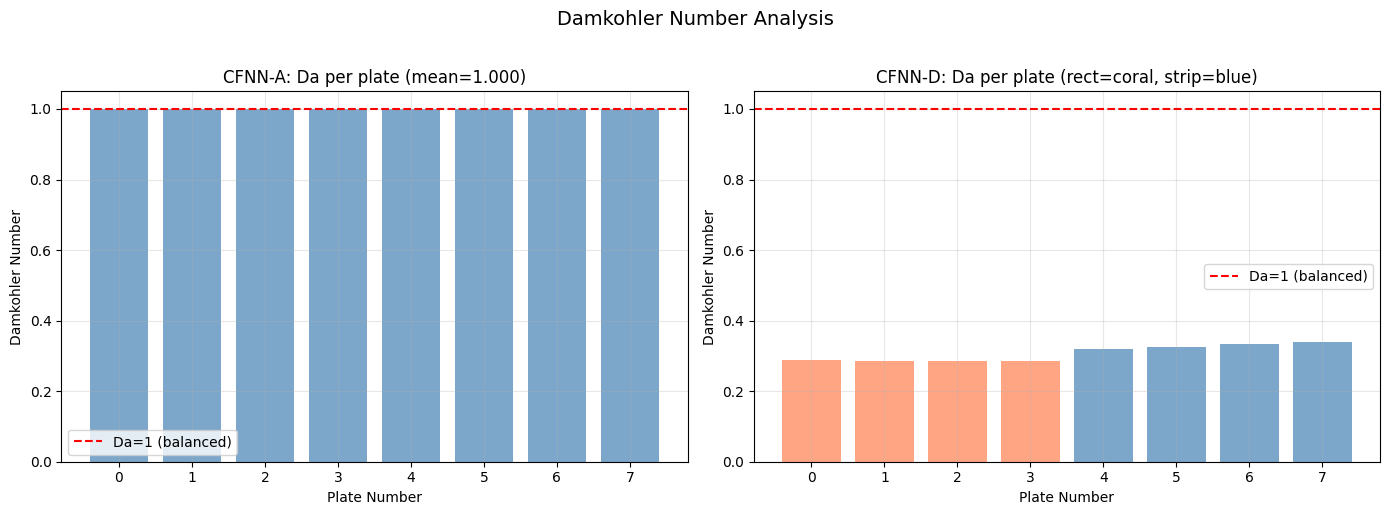

In [11]:
# Visualize Damkohler numbers comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# CFNN-A Damkohler
da_a = diag_a['damkohler']['da_per_plate']
ax1.bar(range(len(da_a)), da_a, color='steelblue', alpha=0.7)
ax1.axhline(y=1.0, color='red', linestyle='--', label='Da=1 (balanced)')
ax1.set_xlabel('Plate Number')
ax1.set_ylabel('Damkohler Number')
ax1.set_title(f'CFNN-A: Da per plate (mean={np.mean(da_a):.3f})')
ax1.legend(); ax1.grid(True, alpha=0.3)

# CFNN-D Damkohler
da_d = diag_d['damkohler']['da_per_plate']
colors = ['coral'] * len(diag_d['damkohler'].get('da_rectifying', [])) + \
         ['steelblue'] * len(diag_d['damkohler'].get('da_stripping', []))
if not colors:
    colors = ['steelblue'] * len(da_d)
ax2.bar(range(len(da_d)), da_d, color=colors, alpha=0.7)
ax2.axhline(y=1.0, color='red', linestyle='--', label='Da=1 (balanced)')
ax2.set_xlabel('Plate Number')
ax2.set_ylabel('Damkohler Number')
ax2.set_title(f'CFNN-D: Da per plate (rect=coral, strip=blue)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Damkohler Number Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

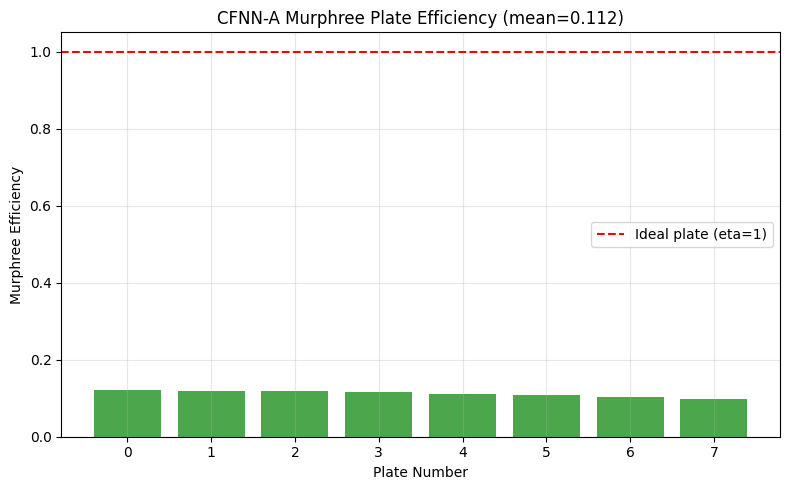

In [12]:
# Murphree Efficiency for CFNN-A
if diag_a['murphree'] is not None:
    eff = diag_a['murphree']['efficiency_per_plate']
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(range(len(eff)), eff, color='green', alpha=0.7)
    ax.axhline(y=1.0, color='red', linestyle='--', label='Ideal plate (eta=1)')
    ax.set_xlabel('Plate Number')
    ax.set_ylabel('Murphree Efficiency')
    ax.set_title(f'CFNN-A Murphree Plate Efficiency (mean={np.mean(eff):.3f})')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Distillation Internals — Rectifying vs Stripping

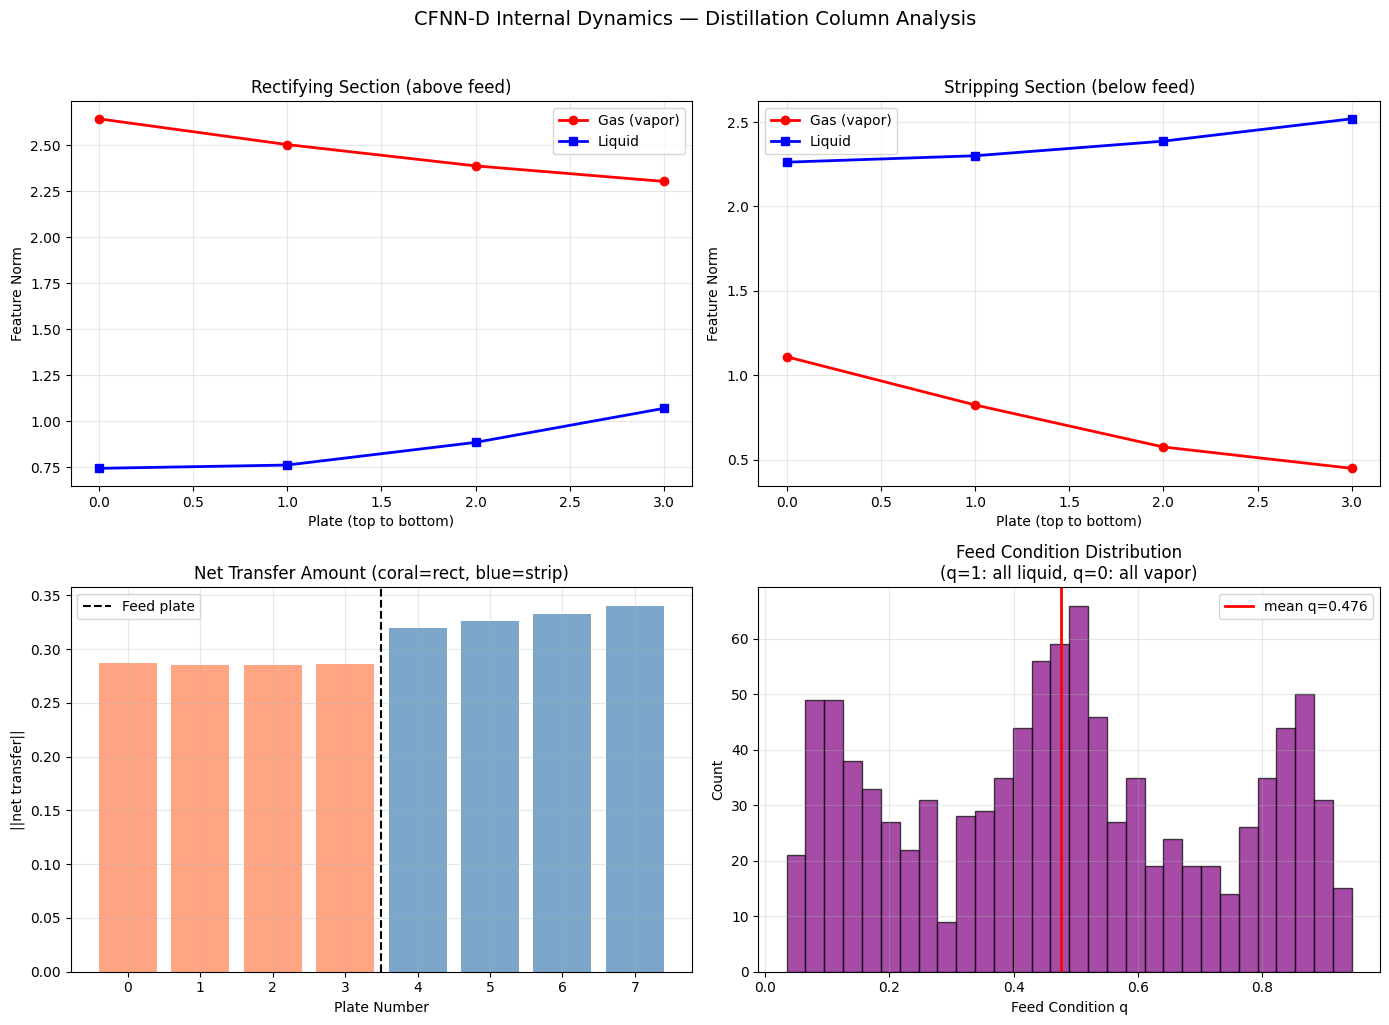

Learned reflux ratio: 0.3175
Learned reboil ratio: 0.2131
Mean feed condition q: 0.4756


In [13]:
# Get CFNN-D intermediates
result_d = model_d.forward_with_intermediates(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gas norms through sections
gas_rect_norms = [g.norm(dim=-1).mean().item() for g in result_d['gas_rect']]
gas_strip_norms = [g.norm(dim=-1).mean().item() for g in result_d['gas_strip']]
liq_rect_norms = [l.norm(dim=-1).mean().item() for l in result_d['liquid_rect']]
liq_strip_norms = [l.norm(dim=-1).mean().item() for l in result_d['liquid_strip']]

# Rectifying section profiles
ax = axes[0, 0]
ax.plot(gas_rect_norms, 'r-o', label='Gas (vapor)', linewidth=2)
ax.plot(liq_rect_norms, 'b-s', label='Liquid', linewidth=2)
ax.set_xlabel('Plate (top to bottom)')
ax.set_ylabel('Feature Norm')
ax.set_title('Rectifying Section (above feed)')
ax.legend(); ax.grid(True, alpha=0.3)

# Stripping section profiles
ax = axes[0, 1]
ax.plot(gas_strip_norms, 'r-o', label='Gas (vapor)', linewidth=2)
ax.plot(liq_strip_norms, 'b-s', label='Liquid', linewidth=2)
ax.set_xlabel('Plate (top to bottom)')
ax.set_ylabel('Feature Norm')
ax.set_title('Stripping Section (below feed)')
ax.legend(); ax.grid(True, alpha=0.3)

# Transfer amounts
ax = axes[1, 0]
delta_rect_norms = [d.norm(dim=-1).mean().item() for d in result_d['deltas_rect']]
delta_strip_norms = [d.norm(dim=-1).mean().item() for d in result_d['deltas_strip']]
all_deltas = delta_rect_norms + delta_strip_norms
colors = ['coral'] * len(delta_rect_norms) + ['steelblue'] * len(delta_strip_norms)
ax.bar(range(len(all_deltas)), all_deltas, color=colors, alpha=0.7)
ax.axvline(x=len(delta_rect_norms) - 0.5, color='black', linestyle='--', label='Feed plate')
ax.set_xlabel('Plate Number')
ax.set_ylabel('||net transfer||')
ax.set_title('Net Transfer Amount (coral=rect, blue=strip)')
ax.legend(); ax.grid(True, alpha=0.3)

# Feed condition distribution
ax = axes[1, 1]
q_values = result_d['feed_q'].squeeze().numpy()
ax.hist(q_values, bins=30, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=q_values.mean(), color='red', linewidth=2, label=f'mean q={q_values.mean():.3f}')
ax.set_xlabel('Feed Condition q')
ax.set_ylabel('Count')
ax.set_title('Feed Condition Distribution\n(q=1: all liquid, q=0: all vapor)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('CFNN-D Internal Dynamics — Distillation Column Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Learned reflux ratio: {result_d['reflux_ratio']:.4f}")
print(f"Learned reboil ratio: {result_d['reboil_ratio']:.4f}")
print(f"Mean feed condition q: {q_values.mean():.4f}")

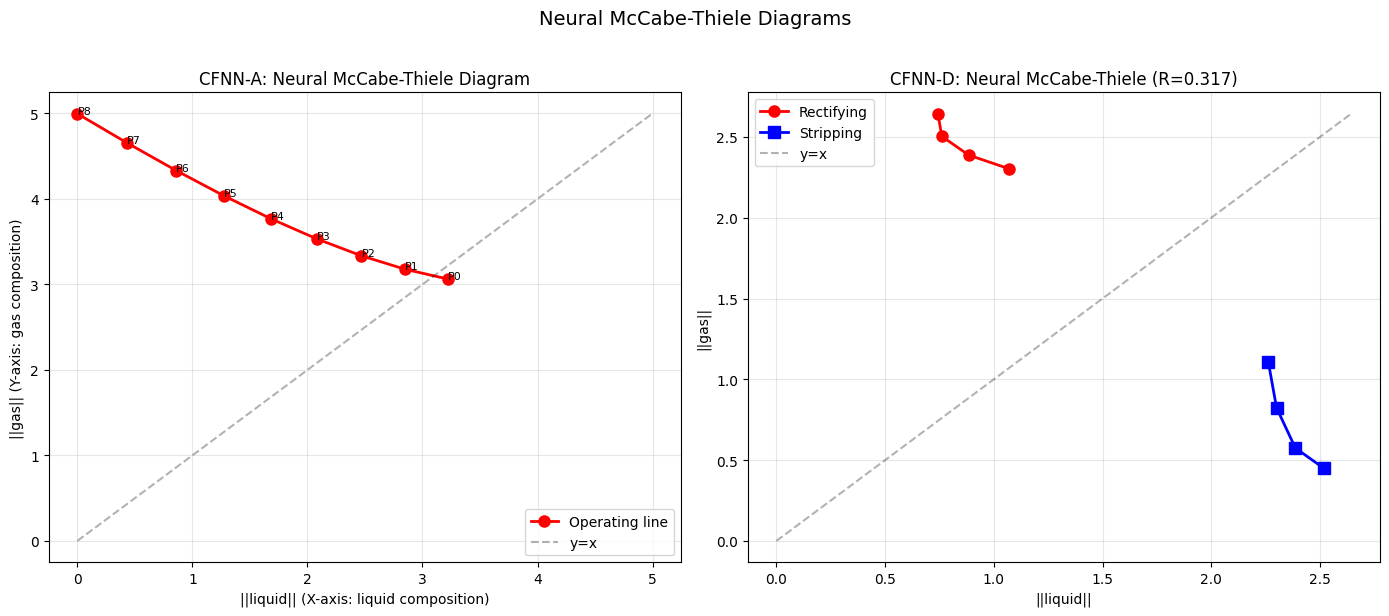

In [14]:
# Operating line data — Neural McCabe-Thiele (CFNN-A)
op_a = operating_line_data(model_a, X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# CFNN-A operating line
if 'gas_norms' in op_a:
    gas_n = op_a['gas_norms']
    liq_n = op_a['liquid_norms']
    # Pad to same length
    min_len = min(len(gas_n), len(liq_n))
    ax1.plot(liq_n[:min_len], gas_n[:min_len], 'ro-', linewidth=2, markersize=8, label='Operating line')
    # 45-degree line (y=x reference)
    max_val = max(max(gas_n[:min_len]), max(liq_n[:min_len]))
    ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    for i in range(min_len):
        ax1.annotate(f'P{i}', (liq_n[i], gas_n[i]), fontsize=8)
    ax1.set_xlabel('||liquid|| (X-axis: liquid composition)')
    ax1.set_ylabel('||gas|| (Y-axis: gas composition)')
    ax1.set_title('CFNN-A: Neural McCabe-Thiele Diagram')
    ax1.legend(); ax1.grid(True, alpha=0.3)

# CFNN-D operating lines (separate rect/strip)
op_d = operating_line_data(model_d, X_scaled)
if 'gas_rect_norms' in op_d:
    gr = op_d['gas_rect_norms']
    lr = op_d['liquid_rect_norms']
    gs = op_d['gas_strip_norms']
    ls = op_d['liquid_strip_norms']
    min_r = min(len(gr), len(lr))
    min_s = min(len(gs), len(ls))
    ax2.plot(lr[:min_r], gr[:min_r], 'ro-', linewidth=2, markersize=8, label='Rectifying')
    ax2.plot(ls[:min_s], gs[:min_s], 'bs-', linewidth=2, markersize=8, label='Stripping')
    max_val = max(max(gr[:min_r] + gs[:min_s]), max(lr[:min_r] + ls[:min_s]))
    ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='y=x')
    ax2.set_xlabel('||liquid||')
    ax2.set_ylabel('||gas||')
    ax2.set_title(f'CFNN-D: Neural McCabe-Thiele (R={op_d["reflux_ratio"]:.3f})')
    ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Neural McCabe-Thiele Diagrams', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Alpha/Beta Evolution — Transfer Coefficient Analysis

In [15]:
# Compare alpha statistics between CFNN-A and CFNN-D
stats_a = alpha_statistics(model_a)
stats_d = alpha_statistics(model_d)

print("=== CFNN-A Transfer Coefficients ===")
for a in stats_a['alphas']:
    print(f"  {a['name']}: alpha={a['mean']:.4f} [{a['min']:.4f}, {a['max']:.4f}]")

print("\n=== CFNN-D Transfer Coefficients ===")
for a in stats_d['alphas']:
    print(f"  {a['name']}: alpha={a['mean']:.4f} [{a['min']:.4f}, {a['max']:.4f}]")
for b in stats_d['betas']:
    print(f"  {b['name']}: beta={b['mean']:.4f} [{b['min']:.4f}, {b['max']:.4f}]")

print(f"\nCFNN-A NTU: {number_of_transfer_units(model_a, X_scaled):.4f}")
print(f"CFNN-D NTU: {number_of_transfer_units(model_d, X_scaled):.4f}")

=== CFNN-A Transfer Coefficients ===
  _shared_plate: alpha=0.1125 [0.0967, 0.1273]

=== CFNN-D Transfer Coefficients ===
  _rect_plate: alpha=0.1130 [0.0982, 0.1401]
  _strip_plate: alpha=0.1013 [0.0911, 0.1141]
  _rect_plate: beta=0.0502 [0.0422, 0.0580]
  _strip_plate: beta=0.0550 [0.0477, 0.0648]

CFNN-A NTU: 0.8520
CFNN-D NTU: 1.5400


---
## Done!

**Phase 2 Complete.** Key findings:
- CFNN-D introduces bidirectional transfer (condensation + vaporization)
- Feed plate + q-line split input between gas/liquid streams
- Reflux and reboil are **learnable** — the network optimizes its own recycle ratios
- Damkohler numbers and Murphree efficiency provide ChemE-interpretable diagnostics

**Next steps (Phase 3):**
- McCabe-Thiele publication-quality plots
- Concentration profile animations
- Theory notebook with mathematical derivations